In [165]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from sklearn.decomposition import PCA

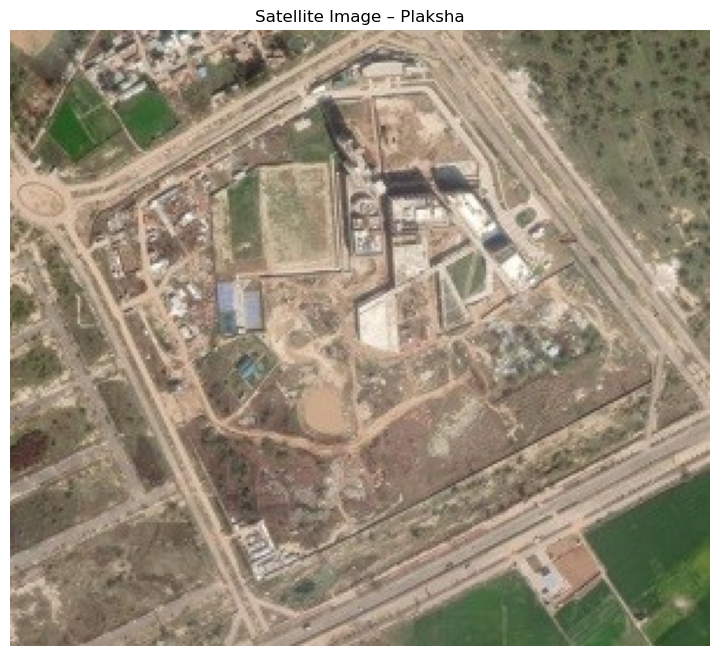

In [169]:
#Step 2: Load the given image and read it using OpenCV
image = cv2.imread('sat_image_plaksha.jpg')
plt.figure(figsize=(10, 8))
image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
plt.imshow(image_rgb)
plt.title("Satellite Image – Plaksha")
plt.axis('off')
plt.show()

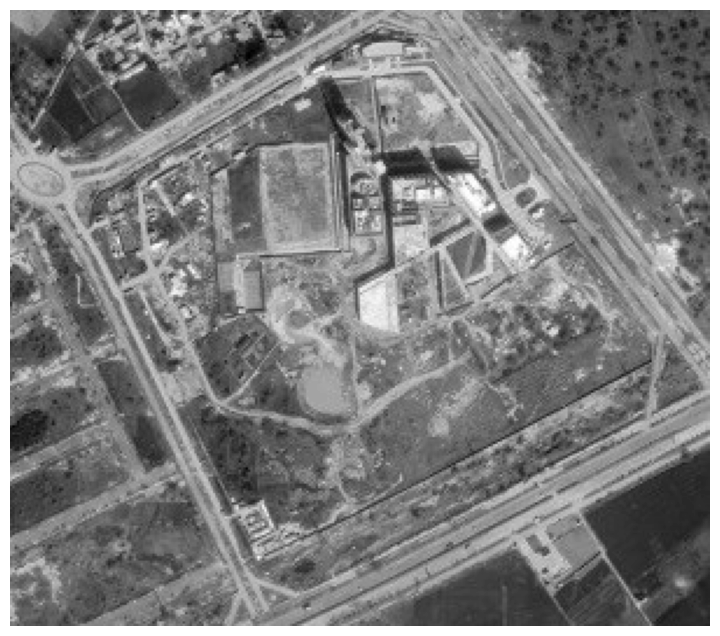

In [175]:
#Step 3: Convert the image to grayscale
gray_image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
plt.figure(figsize=(10, 8))
plt.imshow(gray_image, cmap='gray')
plt.axis('off')
plt.show()

In [179]:
#Step 4: Convert the image to double
image_double = gray_image.astype(np.float64)

In [181]:
#Step 5: Compute the mean of each column (pixels) and subtract it from the image
mean_column = np.mean(image_double, axis=0)
image_mean_subtracted = image_double - mean_column

In [185]:
#Step 6: Compute the covariance matrix
covariance_matrix = np.cov(image_mean_subtracted, rowvar=False)

In [187]:
#Step 7: Get eigen values and eigen vectors.
eigen_values, eigen_vectors = np.linalg.eig(covariance_matrix)

In [189]:
#Step 8: Sort eigen vectors by eigen values.
sorted_indices = np.argsort(eigen_values)[::-1]
eigen_values_sorted = eigen_values[sorted_indices]
eigen_vectors_sorted = eigen_vectors[:, sorted_indices]

In [193]:
#Step 9: Define the number of principal components to keep.
num_components_list = [10, 20, 30, 40, 50, 60, 91,300]

In [195]:
#Step 10: for each components reconstruct the image and display output image.
Output_images = []
for num_components in num_components_list:
    selected_components = eigen_vectors_sorted[:, :num_components]
    projected_data = np.dot(selected_components.T, image_mean_subtracted.T).T
    reconstructed_image = np.dot(selected_components, projected_data.T).T + mean_column
    Output_images.append(reconstructed_image)

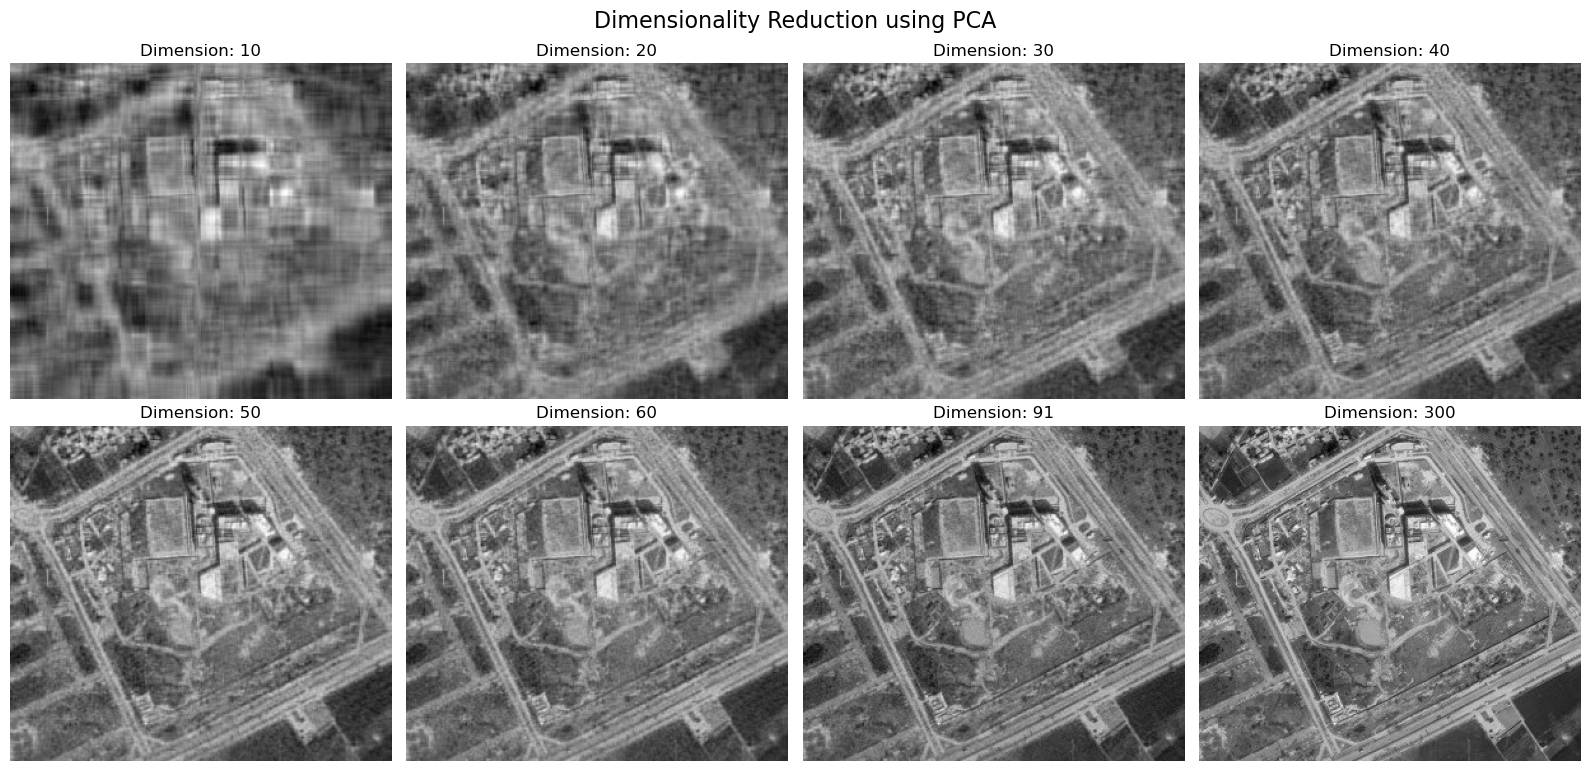

In [151]:
# Step 11: Display the results
plt.figure(figsize=(16, 8))
plt.suptitle("Dimensionality Reduction using PCA", fontsize=16)

for i in range(len(Output_images)):
    plt.subplot(2, 4, i + 1)
    plt.imshow(np.real(Output_images[i]), cmap='gray')
    plt.title(f"Dimension: {num_components_list[i]}")
    plt.axis('off')

plt.tight_layout()
plt.show()

In [207]:
#Step 12: Now using PCA function see how the dim 91 explain the 95% variance in data.
from sklearn.decomposition import PCA

# Number of components
num_components = 91
pca = PCA(n_components=num_components)
pca.fit(image_double)

# Explained variance ratio
explained_variance_ratio = pca.explained_variance_ratio_
cumulative_variance = explained_variance_ratio.sum()

print("Explained variance using 91 components:", cumulative_variance)


Explained variance using 91 components: 0.9505785631863111


### Report:

### Q1: What is the difference between PCA and Feature Selection
Ans:Principal Component Analysis (PCA) and Feature Selection are dimensions reduction methods, however they are differ in their approach. Principal Component Analysis (PCA), on the other hand, is a feature extraction technique. It combines multiple original features to form new features called principal components, which are linear combinations of the original features.The Feature Selection selects a subset of the original features that is important and maintains that subset without modification and interpretation.

### Q2: Why do we standardize features before applying PCA? 
Ans:Before using PCA, we standardize features since PCA uses the variance. When features are of varying scale, the ones with large number ranges will cluster the variance and bias the principal components. Standardization is done so that all the features make equal contributions to the PCA results.

### Q3:What is the importance of Covariance Matrix in PCA?
Ans:It captures the varying features and indicates the features that are likely more independent or dependent on one another. Its eigenvectors define the directions of maximum variance (principal components) and the eigenvalues how much variance that each one of them explains.

### Q4: What are some limitations of PCA?
Ans: Difficult to interpret: Principal components are combinations of original features, so it is hard to know how much each feature contributes.

Information loss: When only a few principal components are selected, some information is always lost.

Linear assumption: Assumes that all the features are a linear relationship with each other. If it is not linear, PCA will not work.

Computational Complexity: if the number of variables is very large.

### Q5: How can we figure out the importance of individual PCs in PCA?
Ans: The significance of the individual principal components (PCs) of PCA is based on their respective eigenvalues or the ratio of explained variance. A PC that has higher eigenvalue describes more variance and hence, is more important. With the computation of the cumulative explained variance, we are able to determine the number of PCs to be retained, typically we want to maintain the number of components to adequately describe around 95 percent of the total variance.